In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv('Combined_Data.csv')

# Which one is reference, which one is backup!?
df['FeH'] = df['FeH_vB'].fillna(df['FeH_Kr'])
df['Age'] = df['Age_Kr'].fillna(df['Age_vB'])

In [14]:
# RMS FeH error between two sets?
notfehna = (df['FeH_Kr']*df['FeH_vB']).notna()
np.sqrt(np.mean((df['FeH_Kr']-df['FeH_vB']).loc[notfehna]))

0.2324617420963319

In [15]:
# RMS age error between two sets?
notagena = (df['Age_Kr']*df['Age_vB']).notna()
np.sqrt(np.mean((df['Age_Kr']-df['Age_vB']).loc[notagena]))

0.6797906917687124

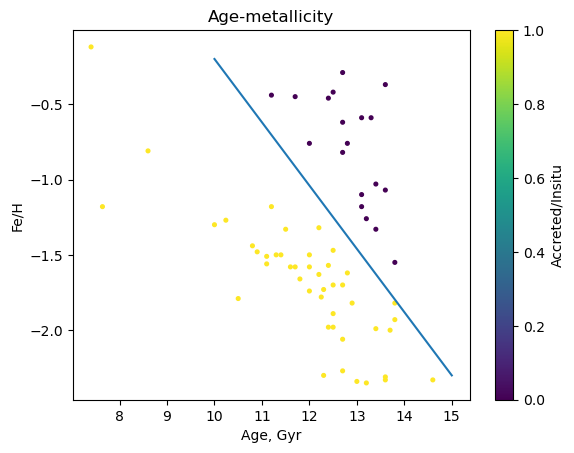

In [50]:
# straight line boundary: 
df['Accreted?'] = (df['FeH'] < ((df['Age']-10) * (-2.1/5)-0.2))

plt.scatter(df['Age'], df['FeH'], c=df['Accreted?'], s=7)
plt.plot([10, 15], [-0.2, -2.3])

plt.title('Age-metallicity')
plt.xlabel('Age, Gyr')
plt.ylabel('Fe/H')
plt.colorbar().set_label('Accreted/Insitu')

In [80]:
# Sun coords
R0 = 8.2          # Sun distance from GC
U, V, W = 11.1, 250.0, 7.25  # Sun speed
l, b = np.radians(df['L']), np.radians(df['B'])

# Add the sun motion to the heliocentric los velocity
df['v_gsr'] = (df['v_r'] + U*np.cos(l)*np.cos(b) + V*np.sin(l)*np.cos(b) + W*np.sin(b))

# Radius from GC in the disk plane
df['R_cyl'] = np.sqrt(df['R_gc']**2 - df['Z']**2)

# Rotation speed per cluster: v_gsr = v_phi * (R0/R) * sin(l) * cos(b)
geom = (R0 / df['R_cyl']) * np.sin(l) * np.cos(b)
df['v_phi'] = df['v_gsr'] / geom

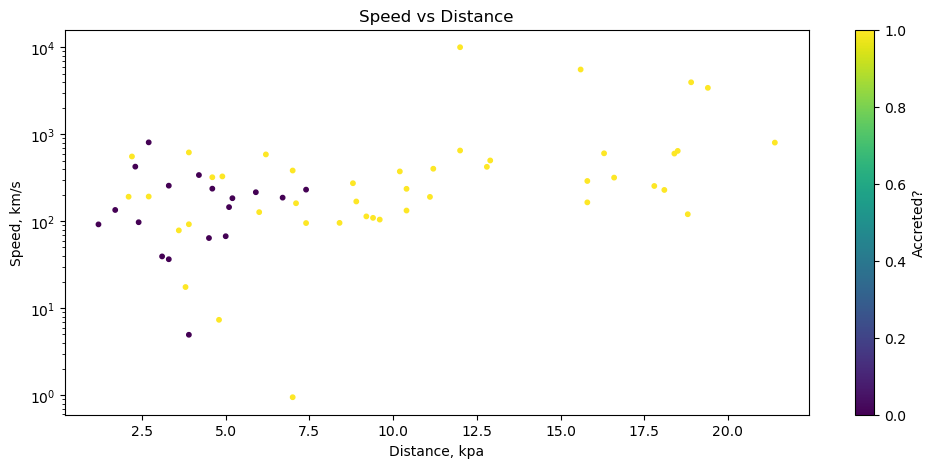

In [81]:
has_FeH = df['FeH'].notna()
plt.figure(figsize=[12, 5])
#plt.scatter(df.loc[~has_FeH, 'R_gc'], np.abs(df.loc[~has_FeH, 'v_phi']), c="black", s=3)
#plt.scatter(df.loc[has_FeH, 'R_gc'], np.abs(df.loc[has_FeH, 'v_phi']), c=df.loc[has_FeH, 'FeH'], cmap="magma", s=10)
plt.scatter(df.loc[has_FeH, 'R_gc'], np.abs(df.loc[has_FeH, 'v_phi']), c=df.loc[has_FeH, 'Accreted?'], cmap="viridis", s=10)

plt.title('Speed vs Distance')
plt.yscale('log')
plt.xlabel('Distance, kpa')
plt.ylabel('Speed, km/s')
plt.colorbar().set_label('Accreted?')

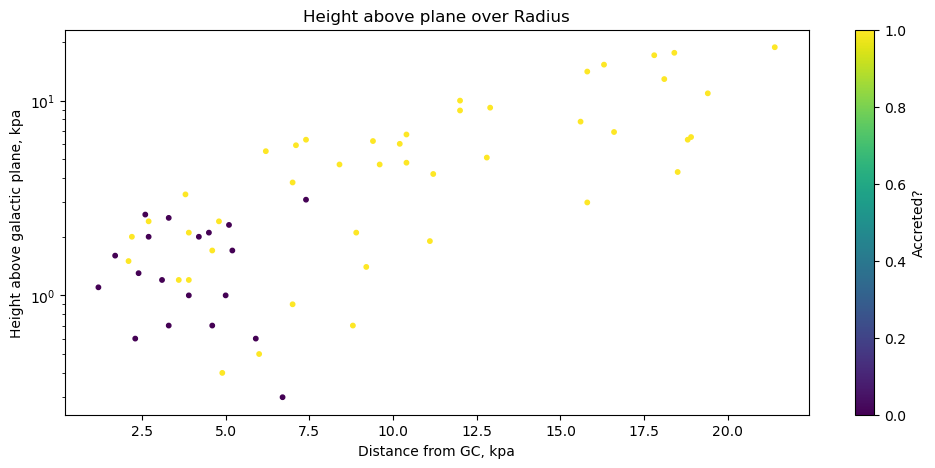

In [82]:
plt.figure(figsize=[12, 5])
#plt.scatter(df.loc[~has_FeH, 'R_gc'], np.abs(df.loc[~has_FeH, 'v_phi']), c="black", s=3)
#plt.scatter(df.loc[has_FeH, 'R_gc'], np.abs(df.loc[has_FeH, 'v_phi']), c=df.loc[has_FeH, 'FeH'], cmap="magma", s=10)
plt.scatter(df.loc[has_FeH, 'R_gc'], np.abs(df.loc[has_FeH, 'Z']), c=df.loc[has_FeH, 'Accreted?'], cmap="viridis", s=10)

plt.title('Height above plane over Radius')
plt.yscale('log')
plt.xlabel('Distance from GC, kpa')
plt.ylabel('Height above galactic plane, kpa')
plt.colorbar().set_label('Accreted?')

Text(0, 0.5, 'Number density, AU')

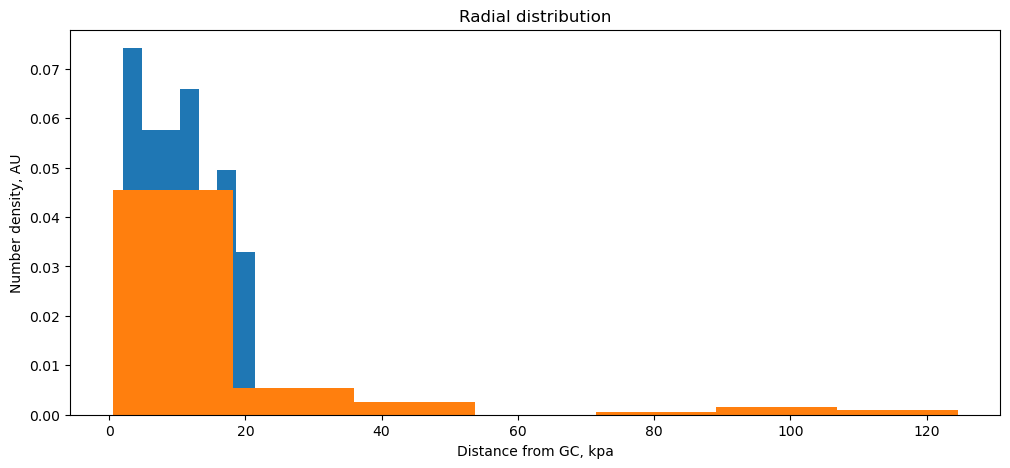

In [91]:
plt.figure(figsize=[12, 5])

plt.hist(df.loc[df['Accreted?'] == 1,'R_gc'], bins=7, density=True)
plt.hist(df.loc[df['Accreted?'] == 0,'R_gc'], bins=7, density=True)
plt.title('Radial distribution')
plt.xlabel('Distance from GC, kpa')
plt.ylabel('Number density, AU')